In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Lib

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import random
import kagglehub
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2

import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50
from transformers import SegformerForSemanticSegmentation

import warnings
warnings.filterwarnings("ignore")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# Config


In [3]:
DATASET = "electraawais/cityscape-dataset"

CITYSCAPES_CLASSES = ["road", "sidewalk", "building", "wall", "fence",
                      "pole", "traffic light", "traffic sign", "vegetation",
                      "terrain", "sky", "person", "rider", "car",
                      "truck", "bus", "train", "motorcycle", "bicycle"]
NUM_CLASSES = len(CITYSCAPES_CLASSES)

IGNORE_INDEX = 255

LABELID_TO_TRAINID = {
    0: 255,
    1: 255,
    2: 255,
    3: 255,
    4: 255,
    5: 255,
    6: 255,
    7: 0,     # road
    8: 1,     # sidewalk
    9: 255,
    10: 255,
    11: 2,    # building
    12: 3,    # wall
    13: 4,    # fence
    14: 255,
    15: 255,
    16: 255,
    17: 5,    # pole
    18: 255,
    19: 6,    # traffic light
    20: 7,    # traffic sign
    21: 8,    # vegetation
    22: 9,    # terrain
    23: 10,   # sky
    24: 11,   # person
    25: 12,   # rider
    26: 13,   # car
    27: 14,   # truck
    28: 15,   # bus
    29: 255,
    30: 255,
    31: 16,   # train
    32: 17,   # motorcycle
    33: 18,   # bicycle
    255: 255
}

CITYSCAPES_COLORS = np.array([
    [128, 64, 128],    # road
    [244, 35, 232],    # sidewalk
    [70, 70, 70],      # building
    [102, 102, 156],   # wall
    [190, 153, 153],   # fence
    [153, 153, 153],   # pole
    [250, 170, 30],    # traffic light
    [220, 220, 0],     # traffic sign
    [107, 142, 35],    # vegetation
    [152, 251, 152],   # terrain
    [70, 130, 180],    # sky
    [220, 20, 60],     # person
    [255, 0, 0],       # rider
    [0, 0, 142],       # car
    [0, 0, 70],        # truck
    [0, 60, 100],      # bus
    [0, 80, 100],      # train
    [0, 0, 230],       # motorcycle
    [119, 11, 32],     # bicycle
], dtype=np.uint8)

IMAGE_HEIGHT = 512
IMAGE_WIDTH = 512

BATCH_SIZE = 2

RANDOMSEED = 42

EPOCHS = 10
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4
SAVE_PATH = '/content/drive/MyDrive/DL Project/Model/segformer_b0_best.pth'

# Load Data

In [4]:
path = kagglehub.dataset_download(DATASET)

print("Path to dataset files:", path)

os.listdir(path)

image_root = os.path.join(path, 'Cityscape Dataset', 'leftImg8bit')
mask_root = os.path.join(path, 'Fine Annotations', 'gtFine')

print("Image root:", image_root)
print("Mask root:", mask_root)

100%|██████████| 11.0G/11.0G [05:12<00:00, 37.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/electraawais/cityscape-dataset/versions/2
Image root: /root/.cache/kagglehub/datasets/electraawais/cityscape-dataset/versions/2/Cityscape Dataset/leftImg8bit
Mask root: /root/.cache/kagglehub/datasets/electraawais/cityscape-dataset/versions/2/Fine Annotations/gtFine


## Pair image-mask

In [5]:
def get_cityscapes_pairs(left_root, gt_root, split="train"):
    left_split_path = os.path.join(left_root, split)
    gt_split_path = os.path.join(gt_root, split)

    image_paths = []

    for root, _, files in os.walk(left_split_path):
        for file in files:
            if file.endswith("_leftImg8bit.png"):
                image_paths.append(os.path.join(root, file))
    image_paths.sort()

    trainid_masks = {}
    labelid_masks = {}

    for root, _, files in os.walk(gt_split_path):
        for file in files:
            if file.endswith("_gtFine_labelTrainIds.png"):
                trainid_masks[os.path.basename(file)] = os.path.join(root, file)
            elif file.endswith("_gtFine_labelIds.png"):
                labelid_masks[os.path.basename(file)] = os.path.join(root, file)

    pairs = []

    for img_path_str in image_paths:
        img_name = os.path.basename(img_path_str)

        trainid_name = img_name.replace(
            "_leftImg8bit.png",
            "_gtFine_labelTrainIds.png"
        )

        labelid_name = img_name.replace(
            "_leftImg8bit.png",
            "_gtFine_labelIds.png"
        )

        if trainid_name in trainid_masks:
            pairs.append((img_path_str, trainid_masks[trainid_name], "trainId"))
        elif labelid_name in labelid_masks:
            pairs.append((img_path_str, labelid_masks[labelid_name], "labelId"))
        else:
            print(f"Missing mask for: {img_path_str}")

    return pairs

train_pairs = get_cityscapes_pairs(image_root, mask_root, split="train")
val_pairs = get_cityscapes_pairs(image_root, mask_root, split="val")

print("Train pairs:", len(train_pairs))
print("Val pairs:", len(val_pairs))

print("\nExample pair:")
print(train_pairs[70])

Train pairs: 2975
Val pairs: 500

Example pair:
('/root/.cache/kagglehub/datasets/electraawais/cityscape-dataset/versions/2/Cityscape Dataset/leftImg8bit/train/aachen/aachen_000070_000019_leftImg8bit.png', '/root/.cache/kagglehub/datasets/electraawais/cityscape-dataset/versions/2/Fine Annotations/gtFine/train/aachen/aachen_000070_000019_gtFine_labelIds.png', 'labelId')


In [6]:
train_pairs, test_pairs = train_test_split(
    train_pairs,
    train_size=2500,
    test_size=475,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

Train: 2500
Val: 500
Test: 475


## Dataset

In [7]:
def convert_labelid_to_trainid(mask):
    train_mask = np.ones_like(mask, dtype=np.uint8) * IGNORE_INDEX

    for label_id, train_id in LABELID_TO_TRAINID.items():
        train_mask[mask == label_id] = train_id

    return train_mask

In [8]:
train_transform = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),

    A.HorizontalFlip(p=0.5),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.3
    ),

    A.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05,
        p=0.3
    ),

    A.GaussianBlur(
        blur_limit=(3, 5),
        p=0.2
    ),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])


val_transform = A.Compose([
    A.Resize(height=IMAGE_HEIGHT, width=IMAGE_WIDTH),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2()
])

In [9]:
class CityscapesSegmentationDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path, mask_type = self.pairs[idx]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)

        image = np.array(image)
        mask = np.array(mask)

        if mask.ndim != 2:
            raise ValueError(f"Mask phải là ảnh grayscale, nhưng nhận shape: {mask.shape}")

        if mask_type == "labelId":
            mask = convert_labelid_to_trainid(mask)

        if self.transform is not None:
            transformed = self.transform(image=image, mask=mask)

            image = transformed["image"]
            mask = transformed["mask"]

        mask = mask.long()

        return {
            "image": image,
            "mask": mask,
            "image_path": str(img_path),
            "mask_path": str(mask_path)
        }

In [10]:
train_dataset = CityscapesSegmentationDataset(
    pairs=train_pairs,
    transform=train_transform
)

val_dataset = CityscapesSegmentationDataset(
    pairs=val_pairs,
    transform=val_transform
)

test_dataset = CityscapesSegmentationDataset(
    pairs=test_pairs,
    transform=val_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 2500
Validation dataset: 500
Test dataset: 475


## DataLoader

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 1250
Validation batches: 250
Test batches: 238


# Function


## SegFormer-B0

In [12]:
def build_segformer_b0(num_classes):
    id2label = {i: label for i, label in enumerate(CITYSCAPES_CLASSES)}
    label2id = {label: i for i, label in id2label.items()}

    model = SegformerForSemanticSegmentation.from_pretrained(
        "nvidia/segformer-b0-finetuned-ade-512-512",
        num_labels=num_classes,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    model.config.semantic_loss_ignore_index = IGNORE_INDEX

    return model

## Segmentation Metrics

In [13]:
class SegmentationMetrics:
    def __init__(self, num_classes, ignore_index=255):
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.reset()

    def reset(self):
        self.confusion_matrix = torch.zeros(
            self.num_classes,
            self.num_classes,
            dtype=torch.int64
        )

    def update(self, preds, targets):
        preds = preds.detach().cpu()
        targets = targets.detach().cpu()

        valid_mask = targets != self.ignore_index

        preds = preds[valid_mask]
        targets = targets[valid_mask]

        if targets.numel() == 0:
            return

        indices = targets * self.num_classes + preds

        cm = torch.bincount(
            indices,
            minlength=self.num_classes ** 2
        ).reshape(self.num_classes, self.num_classes)

        self.confusion_matrix += cm

    def compute(self):
        cm = self.confusion_matrix.float()

        tp = torch.diag(cm)
        fp = cm.sum(dim=0) - tp
        fn = cm.sum(dim=1) - tp

        denominator = tp + fp + fn
        iou = tp / denominator.clamp(min=1)

        valid_classes = denominator > 0
        miou = iou[valid_classes].mean().item()

        pixel_acc = tp.sum() / cm.sum().clamp(min=1)
        pixel_acc = pixel_acc.item()

        return {
            "mIoU": miou,
            "Pixel Accuracy": pixel_acc,
            "Class IoU": iou.numpy()
        }

## Train

In [14]:
def train_model(
    model,
    train_loader,
    val_loader,
    device,
    num_classes,
    ignore_index=255,
    epochs=10,
    lr=5e-5,
    weight_decay=1e-4,
    checkpoint=None,
    save_path="segformer_b0_best.pth",
):
    model = model.to(device)
    model_name = "SegFormer-B0"

    criterion = nn.CrossEntropyLoss(ignore_index=ignore_index)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    best_val_loss = float("inf")
    start_epoch = 0

    if checkpoint is not None:
        ckpt = torch.load(checkpoint, map_location=device)

        model.load_state_dict(ckpt["model"])
        optimizer.load_state_dict(ckpt["optimizer"])
        scheduler.load_state_dict(ckpt["scheduler"])

        history = ckpt["history"]
        best_val_loss = ckpt["best_val_loss"]
        start_epoch = ckpt["epoch"] + 1

        print(f"Resume from epoch {start_epoch}")

    for epoch in range(start_epoch, epochs):

        # Train
        model.train()
        train_loss = 0.0

        for batch in train_loader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            outputs = model(pixel_values=images)
            logits = outputs.logits

            if logits.shape[-2:] != masks.shape[-2:]:
                logits = F.interpolate(
                    logits,
                    size=masks.shape[-2:],
                    mode="bilinear",
                    align_corners=False
                )

            loss = criterion(logits, masks)

            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation loss only
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                images = batch["image"].to(device, non_blocking=True)
                masks = batch["mask"].to(device, non_blocking=True)

                outputs = model(pixel_values=images)
                logits = outputs.logits

                if logits.shape[-2:] != masks.shape[-2:]:
                    logits = F.interpolate(
                        logits,
                        size=masks.shape[-2:],
                        mode="bilinear",
                        align_corners=False
                    )

                loss = criterion(logits, masks)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        scheduler.step(avg_val_loss)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"[{model_name}] Epoch {epoch + 1:02d}/{epochs:02d} | "
            f"lr={current_lr:.6f} | "
            f"train_loss={avg_train_loss:.4f} | "
            f"val_loss={avg_val_loss:.4f}"
        )

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss

            torch.save(
                {
                    "epoch": epoch,
                    "model": model.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "scheduler": scheduler.state_dict(),
                    "best_val_loss": best_val_loss,
                    "history": history,
                    "num_classes": num_classes,
                    "ignore_index": ignore_index,
                    "model_name": model_name,
                    "image_height": IMAGE_HEIGHT,
                    "image_width": IMAGE_WIDTH,
                    "classes": CITYSCAPES_CLASSES,
                },
                save_path,
            )

    print(
        f"Training completed | "
        f"Best Val Loss: {best_val_loss:.4f} | "
        f"Best model saved: {save_path}"
    )

    return model, history

## Eval

In [15]:
def evaluate_model(
    model,
    dataloader,
    device,
    num_classes,
    ignore_index=255,
    criterion=None,
):
    model.eval()

    if criterion is None:
        criterion = nn.CrossEntropyLoss(ignore_index=ignore_index)

    total_loss = 0.0

    metrics = SegmentationMetrics(
        num_classes=num_classes,
        ignore_index=ignore_index
    )

    with torch.no_grad():
        for batch in dataloader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)

            outputs = model(pixel_values=images)
            logits = outputs.logits

            if logits.shape[-2:] != masks.shape[-2:]:
                logits = F.interpolate(
                    logits,
                    size=masks.shape[-2:],
                    mode="bilinear",
                    align_corners=False
                )

            loss = criterion(logits, masks)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            metrics.update(preds, masks)

    avg_loss = total_loss / len(dataloader)
    results = metrics.compute()

    eval_results = {
        "loss": avg_loss,
        "mIoU": results["mIoU"],
        "Pixel Accuracy": results["Pixel Accuracy"],
        "Class IoU": results["Class IoU"]
    }

    return eval_results

In [16]:
def segmentation_report(eval_results, class_names):
    class_iou = eval_results["Class IoU"]

    lines = []
    lines.append(f"{'class':>20s} {'iou':>10s}")
    lines.append("")

    for class_name, iou in zip(class_names, class_iou):
        lines.append(f"{class_name:>20s} {iou:10.4f}")

    lines.append("")
    lines.append(f"{'loss':>20s} {eval_results['loss']:10.4f}")
    lines.append(f"{'mIoU':>20s} {eval_results['mIoU']:10.4f}")
    lines.append(f"{'pixel accuracy':>20s} {eval_results['Pixel Accuracy']:10.4f}")

    return "\n".join(lines)

## Plot

In [30]:
def plot_history(history, title=""):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss", marker=".")
    plt.plot(epochs, history["val_loss"], label="Validation Loss", marker=".")
    plt.title(f"Loss {('- ' + title) if title else ''}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

# Main

## SegFormer-B0

In [18]:
model = build_segformer_b0(NUM_CLASSES)
model = model.to(device)

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

[transformers] You passed `num_labels=19` which is incompatible to the `id2label` map of length `150`.


model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                      
------------------------------+----------+------------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([19])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([19, 256, 1, 1])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


## Train

In [19]:
model, history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    checkpoint=None,
    save_path=SAVE_PATH,
)

[SegFormer-B0] Epoch 01/10 | lr=0.000050 | train_loss=0.7306 | val_loss=0.4196
[SegFormer-B0] Epoch 02/10 | lr=0.000050 | train_loss=0.3633 | val_loss=0.3227
[SegFormer-B0] Epoch 03/10 | lr=0.000050 | train_loss=0.3022 | val_loss=0.2850
[SegFormer-B0] Epoch 04/10 | lr=0.000050 | train_loss=0.2665 | val_loss=0.2649
[SegFormer-B0] Epoch 05/10 | lr=0.000050 | train_loss=0.2449 | val_loss=0.2539
[SegFormer-B0] Epoch 06/10 | lr=0.000050 | train_loss=0.2323 | val_loss=0.2433
[SegFormer-B0] Epoch 07/10 | lr=0.000050 | train_loss=0.2195 | val_loss=0.2365
[SegFormer-B0] Epoch 08/10 | lr=0.000050 | train_loss=0.2129 | val_loss=0.2331
[SegFormer-B0] Epoch 09/10 | lr=0.000050 | train_loss=0.2018 | val_loss=0.2336
[SegFormer-B0] Epoch 10/10 | lr=0.000050 | train_loss=0.1958 | val_loss=0.2361
Training completed | Best Val Loss: 0.2331 | Best model saved: /content/drive/MyDrive/DL Project/Model/segformer_b0_best.pth


## Plot

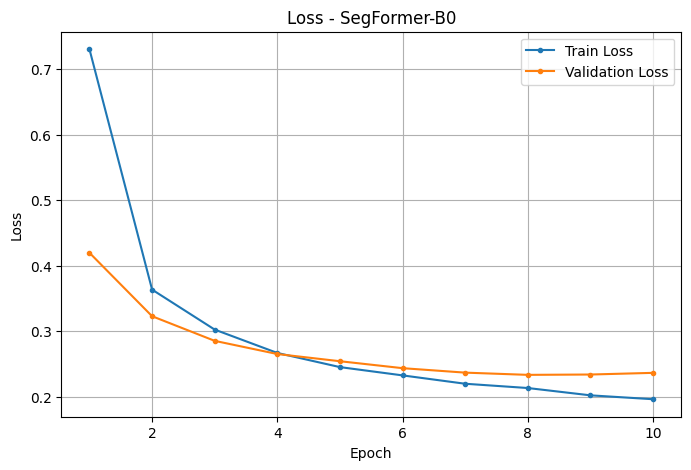

In [31]:
plot_history(
    history,
    title="SegFormer-B0"
)

## Load Checkpoint

In [21]:
checkpoint = torch.load(SAVE_PATH, map_location=device)

model.load_state_dict(checkpoint["model"])
model = model.to(device)
model.eval()

print("Loaded best checkpoint")
print("Best epoch:", checkpoint["epoch"] + 1)
print("Best val loss:", checkpoint["best_val_loss"])

Loaded best checkpoint
Best epoch: 8
Best val loss: 0.23306440091133118


## Eval

In [22]:
eval_results = evaluate_model(
    model=model,
    dataloader=test_loader,
    device=device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX
)

In [23]:
report_text = segmentation_report(
    eval_results=eval_results,
    class_names=CITYSCAPES_CLASSES
)

print(report_text)

               class        iou

                road     0.9692
            sidewalk     0.8116
            building     0.8777
                wall     0.5380
               fence     0.4549
                pole     0.2565
       traffic light     0.2751
        traffic sign     0.4927
          vegetation     0.8763
             terrain     0.6063
                 sky     0.9250
              person     0.5968
               rider     0.1665
                 car     0.8992
               truck     0.5575
                 bus     0.4979
               train     0.6617
          motorcycle     0.4362
             bicycle     0.4917

                loss     0.2114
                mIoU     0.5995
      pixel accuracy     0.9329


# Test Image

In [24]:
def denormalize_image(image_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    image = image_tensor.cpu() * std + mean
    image = image.clamp(0, 1)

    image = image.permute(1, 2, 0).numpy()

    return image

In [25]:
def decode_segmentation_mask(mask):
    h, w = mask.shape

    color_mask = np.zeros((h, w, 3), dtype=np.uint8)

    for class_id in range(NUM_CLASSES):
        color_mask[mask == class_id] = CITYSCAPES_COLORS[class_id]

    color_mask[mask == IGNORE_INDEX] = [0, 0, 0]

    return color_mask

In [26]:
def predict_single_image(model, sample, device):
    model.eval()

    image = sample["image"]
    mask = sample["mask"]

    input_tensor = image.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        logits = outputs.logits

        if logits.shape[-2:] != mask.shape[-2:]:
            logits = F.interpolate(
                logits,
                size=mask.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

        pred_mask = torch.argmax(logits, dim=1).squeeze(0).cpu()

    return image, mask, pred_mask

In [27]:
def visualize_predictions(
    model,
    dataset,
    device,
    num_samples=3
):
    random_indices = random.sample(
        range(len(dataset)),
        num_samples
    )

    plt.figure(figsize=(16, 5 * num_samples))

    for row, idx in enumerate(random_indices):
        sample = dataset[idx]

        image, gt_mask, pred_mask = predict_single_image(
            model=model,
            sample=sample,
            device=device
        )

        image_np = denormalize_image(image)

        gt_mask_np = gt_mask.cpu().numpy()
        pred_mask_np = pred_mask.cpu().numpy()

        gt_color = decode_segmentation_mask(gt_mask_np)
        pred_color = decode_segmentation_mask(pred_mask_np)

        plt.subplot(num_samples, 4, row * 4 + 1)
        plt.imshow(image_np)
        plt.title("Input Image")
        plt.axis("off")

        plt.subplot(num_samples, 4, row * 4 + 2)
        plt.imshow(gt_color)
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(num_samples, 4, row * 4 + 3)
        plt.imshow(pred_color)
        plt.title("Prediction")
        plt.axis("off")

        plt.subplot(num_samples, 4, row * 4 + 4)
        plt.imshow(image_np)
        plt.imshow(pred_color, alpha=0.5)
        plt.title("Overlay")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

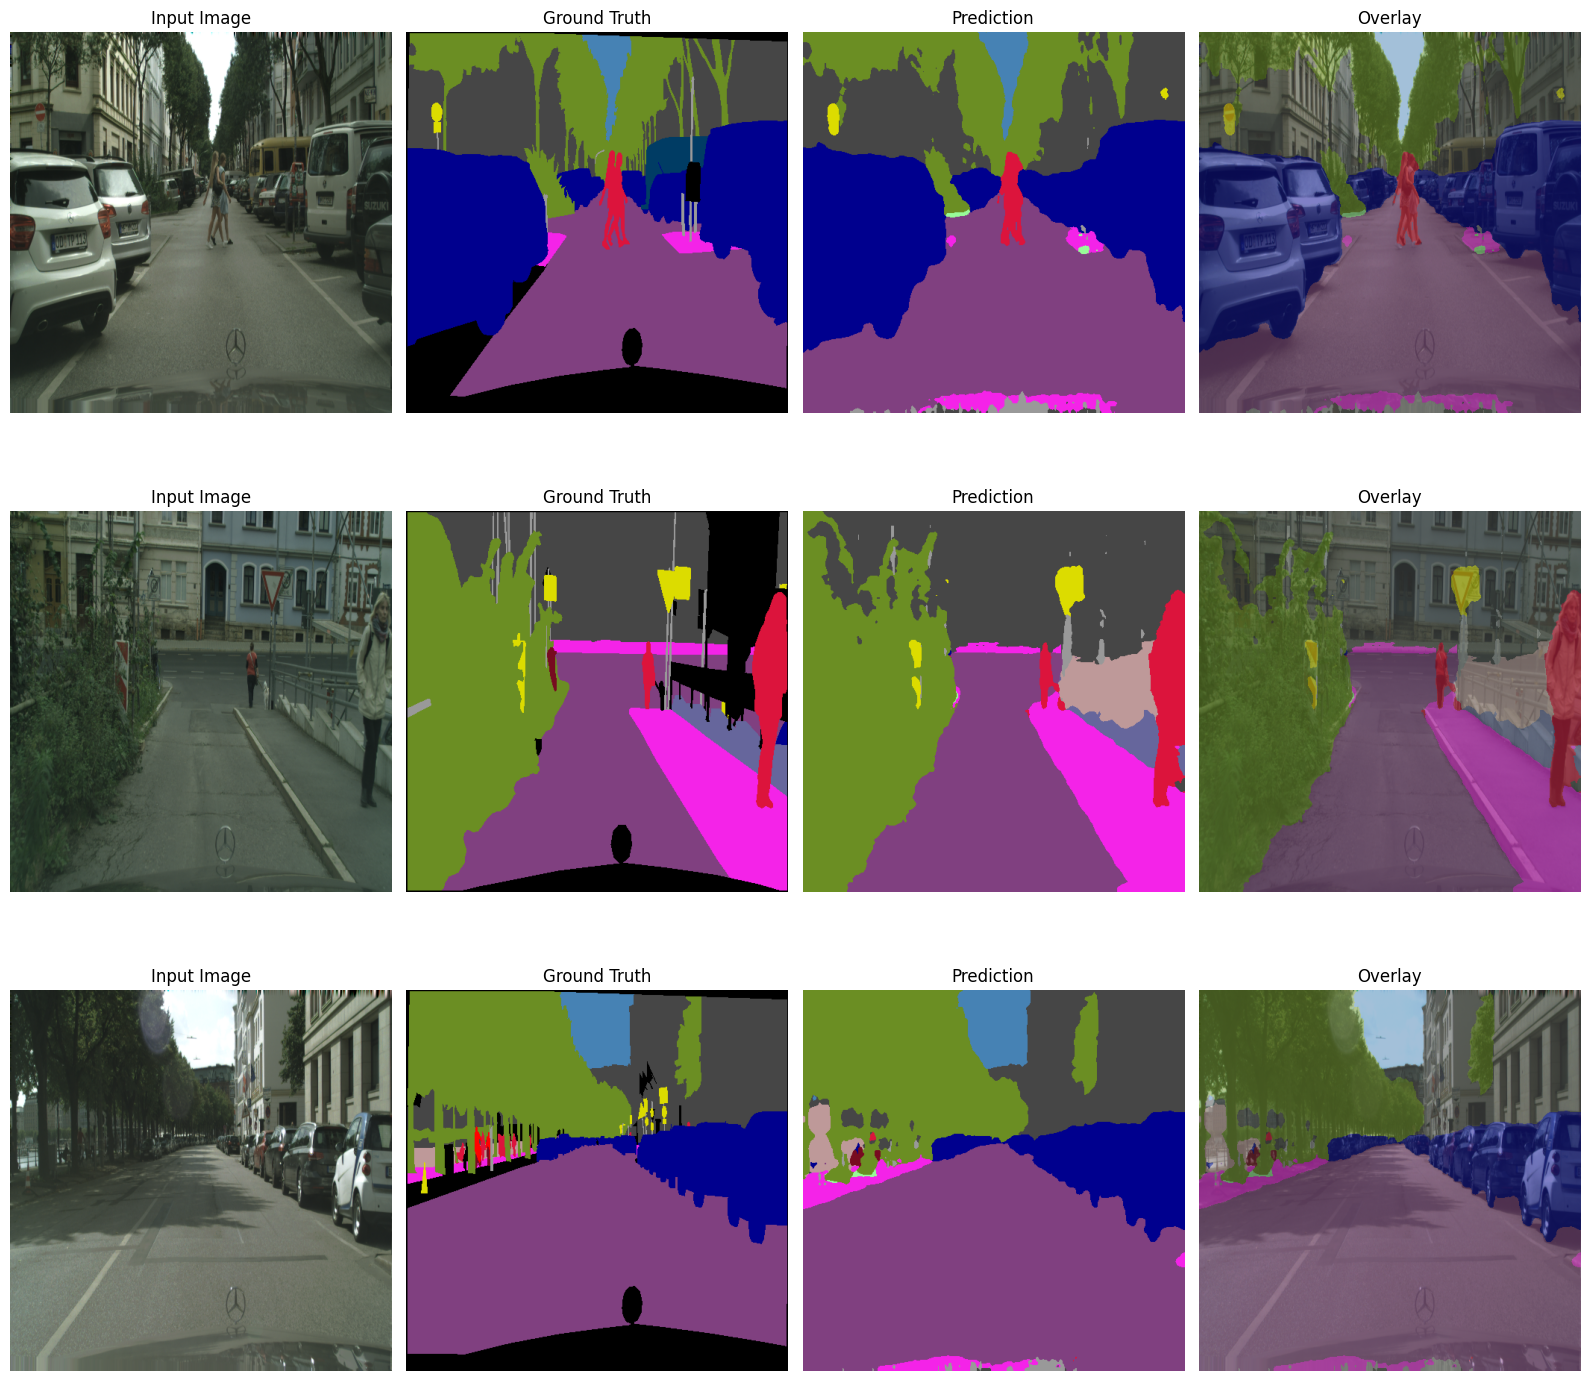

In [29]:
visualize_predictions(
    model=model,
    dataset=test_dataset,
    device=device,
    num_samples=3
)